# **ETL — Extração, Transformação e Carga (PRF)**

primeiro, é necessário instalar e importantas as bibliotecas

In [1]:
!pip install pandas numpy sqlalchemy psycopg2-binary holidays --quiet

import pandas as pd
import numpy as np
import os
import gc
import re
import holidays  # Biblioteca para identificar feriados brasileiros
from sqlalchemy import create_engine


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## **1. Extração dos Dados**

In [ ]:

DATASET = {
    2022: 'dados/prf-multas-dataset/infrações_2022/ajustados_2022',
    2023: 'dados/prf-multas-dataset/infrações_2023/ajustados_2023',
    2024: 'dados/prf-multas-dataset/infrações_2024/ajustados_2024'
}

# filtro para considerar apenas colunas com nomes esperados e não corrompidos/duplicatas
MODELO = [
    'Número do Auto', 'Data da Infração (DD/MM/AAAA)', 'Indicador de Abordagem',
    'Assinatura do Auto', 'Sentido Tráfego', 'UF Infração', 'BR Infração',
    'Km Infração', 'Município', 'Indicador Veículo Estrangeiro', 'UF Placa',
    'Descrição Espécie Veículo', 'Descrição Marca Veículo', 'Descrição Tipo Veículo',
    'Descrição Modelo Veículo', 'Código da Infração', 'Descrição Abreviada Infração',
    'Enquadramento da Infração', 'Início Vigência da Infração', 'Fim Vigência Infração',
    'Medição Infração', 'Hora Infração', 'Medição Considerada', 'Excesso Verificado',
    'Qtd Infrações'
]

# o arquivo 2022_10 foi salvo com os caracteres especiais corrompidos
# achei que era um problema de encoding, por isso coloquei latin-1 e cp1252
# mas em algum momento o arquivo foi corrompido e perdeu os acentos no processo
# mapeamento manual da header para não perder os dados
# é tipo 'se você vir escrito munic[X]pio, finja que está escrito município'
HEADER_FIX = {
    'n\ufffdmero do auto': 'número do auto',
    'data da infra\ufffd\ufffdo (dd/mm/aaaa)': 'data da infração (dd/mm/aaaa)',
    'uf infra\ufffd\ufffdo': 'uf infração',
    'br infra\ufffd\ufffdo': 'br infração',
    'km infra\ufffd\ufffdo': 'km infração',
    'munic\ufffdpio': 'município',
    'descri\ufffd\\ufffdo especie ve\ufffdculo': 'descrição espécie veículo',
    'descri\ufffd\\ufffdo marca ve\ufffdculo': 'descrição marca veículo',
    'descri\ufffd\\ufffdo tipo ve\ufffdculo': 'descrição tipo veículo',
    'c\ufffddigo da infra\ufffd\ufffdo': 'código da infração',
    'descri\ufffd\\ufffdo abreviada infra\ufffd\ufffdo': 'descrição abreviada infração',
    'enquadramento da infra\ufffd\ufffdo': 'enquadramento da infração',
    'in\ufffdcio vig\ufffdncia da infra\ufffd\ufffdo': 'início vigência da infração',
    'fim vig\ufffdncia infra\ufffd\ufffdo': 'fim vigência infração',
    'medi\ufffd\\ufffdo infra\ufffd\ufffdo': 'medição infração',
    'hora infra\ufffd\ufffdo': 'hora infração',
    'medi\ufffd\\ufffdo considerada': 'medição considerada',
    'qtd infra\ufffd\\ufffdes': 'qtd infrações',
    'sentido trafego': 'sentido tráfego',
    'indicador veiculo estrangeiro': 'indicador veículo estrangeiro',
    'descrição especie veículo': 'descrição espécie veículo',
    'descrição modelo veiculo': 'descrição modelo veículo'
}

# Cria um loop para testar os encodings mais comum
def le_csv(path):
  for encoding in ['utf-8','latin-1', 'cp1252']:
    try:
      df = pd.read_csv(path,
                       sep=';',
                       encoding=encoding,
                       low_memory=False, # o low memory é para o pandas não reclamar de colunas com tipos de dados misturado
                       dtype=str, # ELT: força a leitura 100% como texto bruto
                       keep_default_na=False) # ELT: impede que o pandas crie NULLs
      df.columns = [HEADER_FIX.get(c.lower().strip(), c.lower().strip()) for c in df.columns]
      return df
    except:
      continue
  # fallback: força utf-8 ignorando erros
  return pd.read_csv(path, sep=';', encoding='utf-8', errors='replace', low_memory=False)

#  lidando com problema de RAM
def processa_ano(ano, pasta):
    # entra na pasta do ano correspondente e organiza em ordem cronológica
    tabelas = sorted([os.path.join(pasta, p) for p in os.listdir(pasta) if p.endswith('.csv')])

    meses = []  # lista em que cada dataframe de um mês é um elemento
    print(f'=== CARREGANDO DADOS DO ANO: {ano} ===')

    for arquivo_mes in tabelas:
        df_mes = le_csv(arquivo_mes)
        modelo_lower = [p.lower() for p in MODELO]
        colunas_validas = [c for c in df_mes.columns if c in modelo_lower]
        df_mes = df_mes[colunas_validas]
        meses.append(df_mes)

    df_anual = pd.concat(meses, ignore_index=True)#o ignore index é para o pandas reconstruir a numeração
    df_anual.columns = df_anual.columns.str.strip().str.lower()
    print(f"Total {ano}: {len(df_anual):,} registros.")

    # devolve o dataframe anual
    return df_anual

In [3]:
print('Colunas do primeiro arquivo CSV de 2022:')
sample_file_path = sorted([os.path.join(DATASET[2022], p) for p in os.listdir(DATASET[2022]) if p.endswith('.csv')])[0]
df_sample = le_csv(sample_file_path)
display(df_sample.columns)

Colunas do primeiro arquivo CSV de 2022:


Index(['número do auto', 'data da infração (dd/mm/aaaa)',
       'indicador de abordagem', 'assinatura do auto', 'sentido tráfego',
       'uf infração', 'br infração', 'km infração', 'município',
       'indicador veículo estrangeiro', 'uf placa',
       'descrição espécie veículo', 'descrição marca veículo',
       'descrição tipo veículo', 'descrição modelo veículo',
       'código da infração', 'descrição abreviada infração',
       'enquadramento da infração', 'início vigência da infração',
       'fim vigência infração', 'medição infração', 'hora infração',
       'medição considerada', 'excesso verificado', 'qtd infrações'],
      dtype='object')

## **2. Funções Modulares de Transformação**

## Parte Analítica

Juntando os 36 arquivos .csv, a quantidade de instâncias é enorme, de modo que a qualidade e a padronização são fatores que se perdem durante o processo natural de preenchimento das tabelas.

Alguns pontos cruciais importantes a serem mapeados antes da transformação: valores nulos, datas inválidas, horas inválidas, duplicatas e valores únicos.

In [4]:
def diagnosis(df, ano):
  print(f'\n==== DIAGNÓSTICO {ano} ====')
  print("\n── VALORES NULOS ──────────────────────────────────────────")
  qtd_nulos = df.isnull().sum()
  pct_nulos = (qtd_nulos / len(df) * 100).round(2)
  resume = pd.DataFrame({'Nulos': qtd_nulos, '%': pct_nulos})
  resume = resume[resume['Nulos'] > 0].sort_values('%', ascending=False)
  for c, r in resume.iterrows():
    print(f" {c} {r['Nulos']} ({r['%']:>6.2f}%)")

  print("\n── DATAS INVÁLIDAS ────────────────────────────────────────")
  # Utilizando format='mixed' de forma inofensiva no diagnóstico para capturar o cenário real
  datas = pd.to_datetime(df['data da infração (dd/mm/aaaa)'], format='mixed', errors='coerce')
  print("Amostra de datas")
  display(datas.head())
  print(f"DATAS INVÁLIDAS OU NULAS: {datas.isna().sum():,}")
  fora_do_ano = datas[(datas.dt.year != ano) & datas.notna()]
  print(f"FORA DO ANO {ano}: {len(fora_do_ano):,}")

  print("\n── HORAS INVÁLIDAS ────────────────────────────────────────")
  horas = pd.to_numeric(df['hora infração'], errors='coerce')
  print(f"HORAS NÃO NUMÉRICAS: {horas.isna().sum():,}")
  print(f"HORAS FORA DO INTERVALO: {((horas < 0) | (horas > 2359)).sum():,}")

  print("\n── DUPLICATAS ─────────────────────────────────────────────")
  print(f"AUTOS DUPLICADOS: {df.duplicated(subset=['número do auto']).sum():,}")

  print("\n── MEDIÇÕES (CONFERÊNCIA) ─────────────────────────────────")
  print("Medição Infração - Descrição:")
  display(df['medição infração'].describe())
  print("Medição Considerada - Descrição:")
  display(df['medição considerada'].describe())
  print("Amostra de 'número do auto', 'medição infração' e 'medição considerada' (primeiras 50 linhas):")
  display(df[['número do auto', 'medição infração', 'medição considerada']].head(50))

  print("\n── VALORES ÚNICOS (categóricas) ───────────────────────────")
  for col in ['uf infração', 'uf placa', 'indicador veículo estrangeiro', 'indicador de abordagem', 'assinatura do auto', 'sentido tráfego']:
      if col in df.columns:
          print(f"{col}: {sorted(df[col].dropna().unique())}")
  print()

# MEDIDA CONTRA ESGOTAMENTO DE RAM DO COLAB

# cada dataframe tem +300k instâncias por mês
# é inviável carregar todos os arquivos simultaneamente (df global)

# estratégia de processamento particionado em lote
# entra em uma pasta anual por vez
# processa_ano mapeia os CSVs e processa blocos isolados
# diagnosis e o delete é para após extrair o df de um período específico e rodar diagnosis, delete df para quebrar a referência do objeto na memória

for ano, pasta in DATASET.items():
  df_anual = processa_ano(ano, pasta)
  diagnosis(df_anual, ano)
  del df_anual
  gc.collect()

=== CARREGANDO DADOS DO ANO: 2022 ===
Total 2022: 4,135,523 registros.

==== DIAGNÓSTICO 2022 ====

── VALORES NULOS ──────────────────────────────────────────

── DATAS INVÁLIDAS ────────────────────────────────────────
Amostra de datas


0   2022-01-14
1   2022-01-30
2   2022-01-30
3   2022-01-21
4   2022-01-24
Name: data da infração (dd/mm/aaaa), dtype: datetime64[ns]

DATAS INVÁLIDAS OU NULAS: 0
FORA DO ANO 2022: 0

── HORAS INVÁLIDAS ────────────────────────────────────────
HORAS NÃO NUMÉRICAS: 0
HORAS FORA DO INTERVALO: 0

── DUPLICATAS ─────────────────────────────────────────────
AUTOS DUPLICADOS: 0

── MEDIÇÕES (CONFERÊNCIA) ─────────────────────────────────
Medição Infração - Descrição:


count     4135523
unique          5
top       Nenhuma
freq      2799871
Name: medição infração, dtype: object

Medição Considerada - Descrição:


...

Medição Considerada - Descrição:


count     8710022
unique      11663
top             0
freq      2644190
Name: medição considerada, dtype: object

Amostra de 'número do auto', 'medição infração' e 'medição considerada' (primeiras 50 linhas):


,número do auto,medição infração,medição considerada
0,b41eeb6ba2b32f8,Nenhuma,0
1,03555be7021b77f,Nenhuma,0
2,5c7538ca57dbfb5,Nenhuma,0
3,c5ebbd79f9420c6,Nenhuma,0
4,48d1d18550ec986,Nenhuma,0
5,17c2795874e2e17,Nenhuma,0
6,939af76e555af52,Nenhuma,0
7,e95a5d77a90abcf,Nenhuma,0
8,17ab4a1022fe508,Nenhuma,0
9,fd23047cf4e680e,Nenhuma,0



── VALORES ÚNICOS (categóricas) ───────────────────────────
uf infração: ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']
uf placa: ["'-1", '-1', 'AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'N/I', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']
indicador veículo estrangeiro: ['99', 'AR', 'BO', 'BR', 'CL', 'GY', 'MX', 'N', 'PY', 'S', 'UY', 'VE']
indicador de abordagem: ['C', 'S']
assinatura do auto: ['N', 'N/I', 'S']
sentido tráfego: ['C', 'D']



## Conclusões gerais:

> 2022 tem +300k linhas all NULL -> registros corrompidos? -> arquivo corrompido.(por isso criamos  o HEADERFIX na extração de dados)

> Estavamos obtendo 100% de datas inválidas nos 3 anos -> mas descobrimos que era apenas erro de formatação

> valores inválidos para uf placa -> 'N/I', '-1', "'-1", '/', '00', '02', '03', '04', 'OJ', '10', '12', '18', '19', '1C', '1H', '26', '2F', '2G', '2H', '2S', '30', '31', '32', '33', '34', '35', '3C', '3D', '3F', '3G', '3H', '3K', '3N', '3V', '40', '5C', '5N', '5P', '61', '62', '64', '65', '66', '6G', '75', '78', '79', '8A', '8B', '8C', '91', '93', '94', '95', '96', '97', '98', '99', '9A', '9B', '9C', '9E', '9U', '9V',

> indicador veículo estrangeiro -> 2022/2023 era sinalizador, 2024 registrou origem/país

> assinatura do auto -> 2024 tem N/I

## Outras análises

### Descrição Espécie Veículo

In [5]:
for ano, pasta in DATASET.items():
    print(f"\n==== DIAGNÓSTICO 'descrição espécie veículo' PARA O ANO: {ano} ====")

    # Carrega o DataFrame para o ano atual
    df_anual = processa_ano(ano, pasta)

    # Exibe os valores únicos da coluna 'descrição espécie veículo'
    if 'descrição espécie veículo' in df_anual.columns:
        print(f"Valores únicos para 'descrição espécie veículo' em {ano}:")
        display(df_anual['descrição espécie veículo'].unique())
    else:
        print(f"A coluna 'descrição espécie veículo' não foi encontrada para o ano {ano}.")

    # Libera memória
    del df_anual
    gc.collect()


==== DIAGNÓSTICO 'descrição espécie veículo' PARA O ANO: 2022 ====
=== CARREGANDO DADOS DO ANO: 2022 ===
Total 2022: 4,135,523 registros.
Valores únicos para 'descrição espécie veículo' em 2022:


array(['ESPECIAL', 'PASSAGEIRO', 'MISTO', "'-1", 'CARGA', 'TRACAO',
       'TRAÇÃO', 'Não encontrado', 'CORRIDA', 'COLECAO', 'COLEÇÃO',
       'Nao informado', 'COMPETIÇÃO', 'NA'], dtype=object)


==== DIAGNÓSTICO 'descrição espécie veículo' PARA O ANO: 2023 ====
=== CARREGANDO DADOS DO ANO: 2023 ===
Total 2023: 5,946,483 registros.
Valores únicos para 'descrição espécie veículo' em 2023:


array(['PASSAGEIRO', 'ESPECIAL', 'MISTO', 'TRACAO', 'CARGA', "'-1",
       'COLECAO', 'NA', 'Não informado', 'CORRIDA', 'Não encontrado'],
      dtype=object)


==== DIAGNÓSTICO 'descrição espécie veículo' PARA O ANO: 2024 ====
=== CARREGANDO DADOS DO ANO: 2024 ===
Total 2024: 8,710,022 registros.
Valores únicos para 'descrição espécie veículo' em 2024:


array(['TRACAO', 'PASSAGEIRO', 'CARGA', 'ESPECIAL', 'MISTO',
       'Não informado', 'COLECAO', 'CORRIDA', 'TRAÇÃO', 'COLEÇÃO',
       'COMPETIÇÃO'], dtype=object)

Inspecionando os valores únicos da coluna, acreditamos que não há necessidade de normalização, além de NA/Não Informado/Não encontrado, TRACAO/TRAÇÂO e COLECAO/COLEÇÂO

### Descrição tipo e marca **veículo**

In [6]:
for ano, pasta in DATASET.items():
    print(f"\n==== DIAGNÓSTICO 'descrição tipo veículo' PARA O ANO: {ano} ====")

    # Carrega o DataFrame para o ano atual
    df_anual = processa_ano(ano, pasta)

    # Exibe os valores únicos da coluna 'descrição tipo veículo'
    if 'descrição tipo veículo' in df_anual.columns:
        print(f"Valores únicos para 'descrição tipo veículo' em {ano} (todos):")
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            display(df_anual['descrição tipo veículo'].unique())
    else:
        print(f"A coluna 'descrição tipo veículo' não foi encontrada para o ano {ano}.")

    print(f"\n==== DIAGNÓSTICO 'descrição marca veículo' PARA O ANO: {ano} ====")

    # Exibe os valores únicos da coluna 'descrição marca veículo'
    if 'descrição marca veículo' in df_anual.columns:
        print(f"Valores únicos para 'descrição marca veículo' em {ano} (todos):")
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            display(df_anual['descrição marca veículo'].unique())
        print(f"Contagem de valores problemáticos ('-1', 'NA', etc.) para 'descrição marca veículo' em {ano} (ANTES da limpeza):")
        value_counts_raw = df_anual['descrição marca veículo'].astype(str).str.strip().str.upper().value_counts()
        problematic_terms = ['-1', 'NA', 'NAO INFORMADO', 'NÃO ENCONTRADO', 'NÃO INFORMADO']
        problematic_counts = value_counts_raw.loc[value_counts_raw.index.isin(problematic_terms)]
        if not problematic_counts.empty:
            display(problematic_counts)
        else:
            print("Nenhum dos termos problemáticos buscados encontrado nesta coluna.")
    else:
        print(f"A coluna 'descrição marca veículo' não foi encontrada para o ano {ano}.")

    print(f"\n==== DIAGNÓSTICO 'fim vigência infração' PARA O ANO: {ano} ====")

    # Exibe os valores únicos da coluna 'fim vigência infração'
    if 'fim vigência infração' in df_anual.columns:
        print(f"Valores únicos para 'fim vigência infração' em {ano} (todos):")
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            display(df_anual['fim vigência infração'].unique())
    else:
        print(f"A coluna 'fim vigência infração' não foi encontrada para o ano {ano}.")

    # Libera memória
    del df_anual
    gc.collect()


==== DIAGNÓSTICO 'descrição tipo veículo' PARA O ANO: 2022 ====
=== CARREGANDO DADOS DO ANO: 2022 ===
Total 2022: 4,135,523 registros.
Valores únicos para 'descrição tipo veículo' em 2022 (todos):


array(['CAMINHONETE', 'AUTOMOVEL', 'MOTOCICLETA', 'UTILITARIO',
       'CAMINHAO', 'SEMI-REBOQUE', 'REBOQUE', 'CAMIONETA',
       'CAMINHAO TRATOR', 'MOTONETA', 'MICROONIBUS', 'CICLOMOTOR',
       'Não informado', 'ONIBUS', 'NA', 'TRATOR DE RODAS',
       'Não encontrado', 'MOTOR-CASA', 'TRICICLO', 'MOTOCICLO',
       'C. TRATOR', 'SIDE-CAR', 'QUADRICICLO', 'CHASSI/PLATAFORMA'],
      dtype=object)


==== DIAGNÓSTICO 'descrição marca veículo' PARA O ANO: 2022 ====
Valores únicos para 'descrição marca veículo' em 2022 (todos):


array(['FIAT/STRADA ENDURANCE CD', 'VW/GOL 1.0', 'I/BMW R1200 GS', ...,
       'I/LAMBORGHINI G LP5502VB', 'M.BENZ/1215 C TRUKAM CA',
       'I/H.DAVIDSON VRSCAW'], shape=(13173,), dtype=object)

Contagem de valores problemáticos ('-1', 'NA', etc.) para 'descrição marca veículo' em 2022 (ANTES da limpeza):


...

array(['M.BENZ/ACTROS 2546LS', 'HONDA/BIZ 125 ES', 'SR/FACCHINI SRF 4CV',
       ..., 'IMP/SEAT', 'FORD/F1000A SULAM KENTUKI',
       'BRANDY/FOSTI FT125 A'], shape=(16428,), dtype=object)

Contagem de valores problemáticos ('-1', 'NA', etc.) para 'descrição marca veículo' em 2024 (ANTES da limpeza):


descrição marca veículo
NÃO INFORMADO    57559
NA                5968
Name: count, dtype: int64


==== DIAGNÓSTICO 'fim vigência infração' PARA O ANO: 2024 ====
Valores únicos para 'fim vigência infração' em 2024 (todos):


array(['NA', '9'], dtype=object)

- Tipo veiculo: Parece estar consistentes, só tem algum diferenças como 'Não informado;NAO INFORMADO;Não encontrado', mas de modo geral está consistente

- Marca do véiculo: os dados apresentam uma grande variedade de valores, o que é esperado por se tratar de marcas e modelos específicos de veículos. Não foram observadas inconsistências evidentes ou padrões que indiquem problemas de qualidade dos dados. As diferenças encontradas refletem principalmente a diversidade de veículos cadastrados ao longo dos anos, não sendo necessária uma padronização adicional além dos tratamentos gerais de limpeza e preenchimento de valores ausentes

- - fim vigência infração apresentou praticamente 100% com NA, então vamos dropar essa coluna

## Transformando

In [7]:
def get_regiao(uf):
    """ Mapeia as UFs brasileiras para suas respectivas regiões geográficas """
    uf = str(uf).strip().upper()
    norte = ['AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO']
    nordeste = ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']
    centro_oeste = ['DF', 'GO', 'MS', 'MT']
    sudeste = ['ES', 'MG', 'RJ', 'SP']
    sul = ['PR', 'RS', 'SC']

    if uf in norte: return 'Norte'
    if uf in nordeste: return 'Nordeste'
    if uf in centro_oeste: return 'Centro-Oeste'
    if uf in sudeste: return 'Sudeste'
    if uf in sul: return 'Sul'
    return 'Não informado'

def get_sentido_trafego(val):
    """ Traduz de forma legível as siglas de sentido registradas nos autos """
    val = str(val).strip().upper()
    if val == 'C': return 'Crescente'
    if val == 'D': return 'Decrescente'
    return 'Não informado'

def parse_km(val):
    """ Limpa strings complexas ou corrompidas de quilometragem, convertendo-as para numérico flutuante """
    val = str(val).strip()
    if re.match(r'^[0-9]+([,\.][0-9]+)?$', val):
        val = val.replace(',', '.')
        try:
            return float(val)
        except:
            return None
    return None

def clean_tipo_auto(val):
    """ Padroniza e decodifica as siglas que assinam a tipagem jurídica do auto de infração """
    val = str(val).strip().upper()
    if val == 'AI': return 'Auto de Infração'
    if val == 'AIT': return 'Auto de Infração de Trânsito'
    if val == 'ANI': return 'Aviso de Notificação de Infração'
    return val if val != '' else 'NÃO INFORMADO'
# criamos essa função porque verificamos que tinha valores 'problemáticos' que no final representavam a mesma coisa
# ou seja representava Não Informado
def _standardize_common_na_values(val):
    val_str = str(val).strip().upper()
    not_informed_values = ["'-1",'-1', 'NA', 'NAO INFORMADO', 'NÃO ENCONTRADO', 'NÃO INFORMADO']
    if val_str in not_informed_values:
        return 'NÃO INFORMADO'
    return val_str

def clean_especie_veiculo(val):
    """ Normaliza os termos da coluna 'descrição espécie veículo' para padronização. """
    val_processed = _standardize_common_na_values(val)
    if val_processed == 'NÃO INFORMADO':
        return val_processed
    if val_processed in ['TRACAO', 'TRAÇÃO']: return 'TRAÇÃO'
    if val_processed in ['COLECAO', 'COLEÇÃO']: return 'COLEÇÃO'
    if val_processed in ['PASSAGEIRO', 'CARGA', 'ESPECIAL', 'MISTO', 'CORRIDA', 'COMPETIÇÃO']:
        return val_processed
    return 'NÃO INFORMADO'

def clean_tipo_veiculo(val):
    """ Normaliza os termos da coluna 'descrição tipo veículo' para padronização. """
    return _standardize_common_na_values(val)

def clean_marca_veiculo(val):
    """ Normaliza os termos da coluna 'descrição marca veículo' para padronização. """
    return _standardize_common_na_values(val)


## **3. Pipeline de Transformação com Sentidos e Displays de Validação**

Antes de aplicar as transformações em massa, explicamos o sentido analítico de cada bloco de dados e inserimos displays de **Antes** e **Depois** para comprovar visualmente que o dado foi tratado corretamente.

In [8]:
# Simulando a extração do ano de 2024 para demonstração explicativa e validação de qualidade
# Escolhemos só um ano devido ao limite de memória
# e 2024 é o dataset que tem mais dado diversificado
df_raw_2024 = processa_ano(2024, DATASET[2024])

=== CARREGANDO DADOS DO ANO: 2024 ===
Total 2024: 8,710,022 registros.


### **3.1. Tratamento Categórico de Região e Sentido de Tráfego**

* O campo bruto traz apenas siglas de controle interno da PRF (ex: 'C', 'D'). Para um dashboard ou banco de dados analítico (Data Warehouse), precisamos de nomes explícitos e legíveis para que os analistas consigam cruzar o fluxo viário. Além disso, derivamos o campo `regiao_infracao` baseado na UF para permitir agrupamentos de dados em nível nacional.

In [9]:
print("[VALIDAÇÃO ANTES] - Sentido do tráfego e UF brutos:")
display(df_raw_2024[['sentido tráfego', 'uf infração']].head(5))
print("Valores únicos de sentido encontrados:", df_raw_2024['sentido tráfego'].unique())

# Executando a transformação
df_raw_2024['regiao_infracao'] = df_raw_2024['uf infração'].apply(get_regiao)
df_raw_2024['sentido tráfego'] = df_raw_2024['sentido tráfego'].apply(get_sentido_trafego)

print("\n[VALIDAÇÃO DEPOIS] - Campos transformados para formato amigável (Star Schema):")
display(df_raw_2024[['sentido tráfego', 'uf infração', 'regiao_infracao']].head(5))

[VALIDAÇÃO ANTES] - Sentido do tráfego e UF brutos:


,sentido tráfego,uf infração
0,C,MG
1,D,SC
2,D,SC
3,C,SP
4,D,PA


Valores únicos de sentido encontrados: ['C' 'D']

[VALIDAÇÃO DEPOIS] - Campos transformados para formato amigável (Star Schema):


,sentido tráfego,uf infração,regiao_infracao
0,Crescente,MG,Sudeste
1,Decrescente,SC,Sul
2,Decrescente,SC,Sul
3,Crescente,SP,Sudeste
4,Decrescente,PA,Norte


### **3.2. Tratamento Geográfico e Numérico da Rodovia (Kilometragem)**

* O quilômetro da infração é armazenado originalmente como uma string de texto devido à presença de casas decimais digitadas com vírgulas ou pontos. Converter esse campo em um formato flutuante nos permite calcular estatísticas espaciais, distâncias entre acidentes/multas e plotar coordenadas geográficas exatas das rodovias brasileiras.

In [10]:
print("🔍 [VALIDAÇÃO ANTES] - Quilometragem como Texto Bruto:")
display(df_raw_2024[['km infração']].head(5))
print("Tipo de dado original:", df_raw_2024['km infração'].dtype)

# Executando a transformação
df_raw_2024['km infração'] = df_raw_2024['km infração'].apply(parse_km).fillna(0.0)

print("\n✅ [VALIDAÇÃO DEPOIS] - Quilometragem convertida e limpa para Float:")
display(df_raw_2024[['km infração']].head(5))
print("Novo tipo de dado:", df_raw_2024['km infração'].dtype)

🔍 [VALIDAÇÃO ANTES] - Quilometragem como Texto Bruto:


,km infração
0,685
1,2
2,2
3,171
4,19


Tipo de dado original: object

✅ [VALIDAÇÃO DEPOIS] - Quilometragem convertida e limpa para Float:


,km infração
0,685.0
1,2.0
2,2.0
3,171.0
4,19.0


Novo tipo de dado: float64


### **3.3. Normalização de Veículos Estrangeiros e UF de Origem da Placa**

* Identificamos no diagnóstico que o indicador de veículo estrangeiro mudou de padrão ao longo do tempo (virando códigos de países em 2024). Padronizá-lo em formato binário ('S' ou 'N') resolve a quebra histórica do dataset. Em paralelo, o campo `uf placa` contém sujeiras de sistemas legados da PRF (como números `-1` ou `/`). Filtrar e converter essas inconsistências para marcas padronizadas de dados ignorados (`EX` para Exterior e `N/I` para Não Informado) evita que dados nulos quebrem o relacionamento das Surrogate Keys na tabela fato.

In [11]:
# Função nomeada complementar para UF Placa
def classifica_uf_placa_final(uf):
    ufs_validas = {
        'AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MT', 'MS',
        'MG', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 'RS', 'SC', 'SP', 'SE', 'TO', 'RO', 'RR'
    }
    uf = str(uf).strip().upper()
    if uf in ufs_validas: return uf
    if uf in ['N/I', 'EX']: return uf
    if uf == '/': return 'N/I'
    if uf.replace("'", "").replace("-", "").strip() == '1': return 'N/I'
    if len(uf) == 2 and any(c.isdigit() for c in uf): return 'EX'
    return 'N/I'


In [12]:
print("🔍 [VALIDAÇÃO ANTES] - Veículo Estrangeiro e UF da Placa com caracteres inválidos:")
print("Valores brutos da Placa (Amostra):", df_raw_2024['uf placa'].unique())

# Dicionário de normalização estruturada (evitando lambdas complexos)
PAISES_ESTRANGEIROS = {'AR', 'BO', 'CL', 'GY', 'MX', 'PY', 'UY', 'VE'}
mapa_estrangeiro = {'S': 'S', 'N': 'N', 'BR': 'N', '/': 'N/I', '99': 'N/I', '': 'N/I'}
for pais in PAISES_ESTRANGEIROS:
    mapa_estrangeiro[pais] = 'S'

# Aplicando transformações limpas
df_raw_2024['indicador veículo estrangeiro'] = df_raw_2024['indicador veículo estrangeiro'].map(mapa_estrangeiro).fillna('N/I')
df_raw_2024['uf placa'] = df_raw_2024['uf placa'].apply(classifica_uf_placa_final)

print("\n✅ [VALIDAÇÃO DEPOIS] - Placas e Indicadores Limpos e Padronizados:")
display(df_raw_2024[['indicador veículo estrangeiro', 'uf placa']].head(5))
print("Valores finais consolidados de UF Placa:", df_raw_2024['uf placa'].unique())

🔍 [VALIDAÇÃO ANTES] - Veículo Estrangeiro e UF da Placa com caracteres inválidos:
Valores brutos da Placa (Amostra): ['MG' 'SC' 'PR' 'RS' 'MT' 'MS' 'PE' 'PB' 'SE' 'PA' 'TO' 'PI' 'SP' 'DF'
 'MA' 'BA' 'RN' 'CE' 'GO' 'ES' "'-1" 'RJ' 'AC' 'AL' 'RO' 'AM' 'AP' 'RR'
 '-1' 'N/I']

✅ [VALIDAÇÃO DEPOIS] - Placas e Indicadores Limpos e Padronizados:


,indicador veículo estrangeiro,uf placa
0,N,MG
1,N,SC
2,N,SC
3,N,PR
4,N,RS


Valores finais consolidados de UF Placa: ['MG' 'SC' 'PR' 'RS' 'MT' 'MS' 'PE' 'PB' 'SE' 'PA' 'TO' 'PI' 'SP' 'DF'
 'MA' 'BA' 'RN' 'CE' 'GO' 'ES' 'N/I' 'RJ' 'AC' 'AL' 'AM' 'AP']


### **3.4. Consolidação de Campos de Tempo e Limpeza Numérica Final**

* Transformamos a string textual de data em objetos nativos de data do Pandas (`datetime64`). A partir disso, extraímos de forma nativa o dia, mês, ano e trimestre. Para o **dia** da semana, mapeamos os resultados em inglês gerados pela máquina diretamente para o português usando um dicionário fixo. Por fim, calculamos feriados nacionais automaticamente.

In [13]:
df_raw_2024['dia'] = df_raw_2024['data da infração (dd/mm/aaaa)'].dt.day
df_raw_2024['mes'] = df_raw_2024['data da infração (dd/mm/aaaa)'].dt.month
df_raw_2024['ano'] = df_raw_2024['data da infração (dd/mm/aaaa)'].dt.year
df_raw_2024['trimestre'] = df_raw_2024['data da infração (dd/mm/aaaa)'].dt.quarter

dias_map = {
    'Monday': 'Segunda-feira', 'Tuesday': 'Terça-feira', 'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira', 'Friday': 'Sexta-feira', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df_raw_2024['dia_semana'] = df_raw_2024['data da infração (dd/mm/aaaa)'].dt.day_name().map(dias_map).fillna('Não Informado')

br_holidays = holidays.Brazil(years=[2024])
# Convertendo os feriados para o mesmo tipo datetime da coluna
df_raw_2024['is_feriado'] = df_raw_2024['data da infração (dd/mm/aaaa)'].isin((list(br_holidays)))

# Tratamento de floats de medição viária
float_columns = ['medição considerada', 'excesso verificado']
for col in float_columns:
    df_raw_2024[col] = df_raw_2024[col].astype(str).str.replace(',', '.', regex=False)
    df_raw_2024[col] = pd.to_numeric(df_raw_2024[col], errors='coerce').fillna(0.0).astype(float)

# Ajuste de quantidades padrão
df_raw_2024['qtd infrações'] = pd.to_numeric(df_raw_2024['qtd infrações'], errors='coerce').fillna(1).astype(int)

print("✅ [VALIDAÇÃO FINAL DA TRANSFORMAÇÃO] - Visualização Geral do Dataframe Higienizado:")
display(df_raw_2024[['data da infração (dd/mm/aaaa)', 'dia_semana', 'is_feriado', 'medição considerada', 'qtd infrações']].head(5))


AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
print(df_raw_2024['is_feriado'].value_counts())

In [ ]:
# Liberando memória do dataframe de teste
if 'df_raw_2024' in locals():
    del df_raw_2024
gc.collect()

OBS sobre enquadramento da infração: Essa é uma coluna bastante complicada, porque tem muitos artigos diferentes

## **4. Função Consolidada do Pipeline**

Esta função envelopa todas as limpezas validadas acima em um único bloco de execução rápida para processar todos os anos históricos.

In [14]:
def transform_completo(df, ano):
    df = df.dropna(subset=['número do auto'])
    df['data da infração (dd/mm/aaaa)'] = pd.to_datetime(df['data da infração (dd/mm/aaaa)'], format='%Y-%m-%d', errors='coerce')
    df = df.dropna(subset=['data da infração (dd/mm/aaaa)'])

    # Execução sequencial das lógicas modulares
    df['regiao_infracao'] = df['uf infração'].apply(get_regiao)
    df['sentido tráfego'] = df['sentido tráfego'].apply(get_sentido_trafego)
    df['km infração'] = df['km infração'].apply(parse_km).fillna(0.0)
    df['assinatura do auto'] = df['assinatura do auto'].apply(clean_tipo_auto)

    # Nova limpeza para 'descrição espécie veículo'
    df['descrição espécie veículo'] = df['descrição espécie veículo'].apply(clean_especie_veiculo)

    # Nova limpeza para 'descrição tipo veículo'
    df['descrição tipo veículo'] = df['descrição tipo veículo'].apply(clean_tipo_veiculo)
    
    # Nova limpeza para 'descrição marca veículo'
    df['descrição marca veículo'] = df['descrição marca veículo'].apply(clean_marca_veiculo)

    # Indicador Estrangeiro
    PAISES_ESTRANGEIROS = {'AR', 'BO', 'CL', 'GY', 'MX', 'PY', 'UY', 'VE'}
    mapa_estrangeiro = {'S': 'S', 'N': 'N', 'BR': 'N', '/': 'N/I', '99': 'N/I'}
    for pais in PAISES_ESTRANGEIROS: mapa_estrangeiro[pais] = 'S'
    df['indicador veículo estrangeiro'] = df['indicador veículo estrangeiro'].map(mapa_estrangeiro).fillna('N/I')

    # UF Placa
    df['uf placa'] = df['uf placa'].apply(classifica_uf_placa_final)

    # Tempo
    df['data da infração (dd/mm/aaaa)'] = pd.to_datetime(df['data da infração (dd/mm/aaaa)'], format='%Y-%m-%d', errors='coerce')
    df['dia'] = df['data da infração (dd/mm/aaaa)'].dt.day
    df['mes'] = df['data da infração (dd/mm/aaaa)'].dt.month
    df['ano'] = df['data da infração (dd/mm/aaaa)'].dt.year
    df['trimestre'] = df['data da infração (dd/mm/aaaa)'].dt.quarter

    dias_map = {
        'Monday': 'Segunda-feira', 'Tuesday': 'Terça-feira', 'Wednesday': 'Quarta-feira',
        'Thursday': 'Quinta-feira', 'Friday': 'Sexta-feira', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
    }
    df['dia_semana'] = df['data da infração (dd/mm/aaaa)'].dt.day_name().map(dias_map).fillna('Não Informado')

    br_holidays = holidays.Brazil(years=[ano])
    # Convertendo os feriados para o mesmo tipo datetime da coluna
    df['is_feriado'] = df['data da infração (dd/mm/aaaa)'].isin(pd.to_datetime(list(br_holidays)))

    # Tratamento numérico e de strings em lote categórico
    text_columns = ['uf infração', 'município', 'descrição modelo veículo', 'descrição abreviada infração', 'enquadramento da infração']
    df[text_columns] = df[text_columns].fillna('NÃO INFORMADO').replace('', 'NÃO INFORMADO')

    df['código da infração'] = pd.to_numeric(df['código da infração'], errors='coerce').fillna(0).astype(int)
    df['qtd infrações'] = pd.to_numeric(df['qtd infrações'], errors='coerce').fillna(1).astype(int)

    float_columns = ['medição considerada', 'excesso verificado']
    for col in float_columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0).astype(float)

    return df

## **5. Geração do Esquema Estrela (Star Schema)**

### Transformando e guardando no parquet

In [15]:
!pip install fastparquet
import os



# Mapeamento para canonicalizar nomes de colunas, convertendo tudo com acento
COLUNAS_CANONICAS_MAP = {
    'numero do auto': 'número do auto',
    'data da infracao (dd/mm/aaaa)': 'data da infração (dd/mm/aaaa)',
    'indicador de abordagem': 'indicador de abordagem',
    'assinatura do auto': 'assinatura do auto',
    'sentido trafego': 'sentido tráfego',
    'uf infracao': 'uf infração',
    'br infracao': 'br infração',
    'km infracao': 'km infração',
    'municipio': 'município',
    'indicador veiculo estrangeiro': 'indicador veículo estrangeiro',
    'uf placa': 'uf placa',
    'descricao especie veiculo': 'descrição espécie veículo',
    'descricao marca veiculo': 'descrição marca veículo',
    'descricao tipo veiculo': 'descrição tipo veículo',
    'descricao modelo veiculo': 'descrição modelo veículo',
    'codigo da infracao': 'código da infração',
    'descricao abreviada infracao': 'descrição abreviada infração',
    'enquadramento da infracao': 'enquadramento da infração',
    'inicio vigencia da infracao': 'início vigência da infração',
    'fim vigencia infracao': 'fim vigência infração',
    'medicao infracao': 'medição infração',
    'hora infracao': 'hora infração',
    'medicao considerada': 'medição considerada',
    'excesso verificado': 'excesso verificado',
    'qtd infracoes': 'qtd infrações'
}

# transformar e guardar em Parquet
arquivos_parquet = []
DIRETORIO_BASE = os.getcwd() # fica mais fácil em vez de ficar mudando

for ano, pasta in DATASET.items():
    print(f"A processar e a guardar Parquet para o ano {ano}...")

    # Listar os arquivos CSV para o ano atual
    tabelas_mensais = sorted([
        os.path.join(pasta, p) for p in os.listdir(pasta)
        if p.endswith('.csv')
    ])

    total_registros_ano = 0
    for arquivo_mes in tabelas_mensais:
        print(f"  Processando {os.path.basename(arquivo_mes)}...")
        df_mes_raw = le_csv(arquivo_mes)

        # Canonicalizar os nomes das colunas após a leitura inicial
        df_mes_raw.columns = [COLUNAS_CANONICAS_MAP.get(col, col) for col in df_mes_raw.columns]

        # modelo_lower deve ser definido aqui para cada iteração do loop, garantindo que o MODELO atualizado seja usado
        modelo_lower = [p.lower() for p in MODELO]

        # Garante que o DataFrame tenha todas as colunas esperadas de `modelo_lower`,
        # adicionando-as com NaN se estiverem faltando e removendo outras colunas.
        # 'gravidade_infracao' é adicionada em transform_completo, não precisa estar aqui.
        df_mes_raw = df_mes_raw.reindex(columns=modelo_lower)

        df_mes_transformado = transform_completo(df_mes_raw, ano) #etapa de limpeza

        # Caminho do ficheiro Parquet mensal
        # Extrai o nome do arquivo CSV sem a extensão para usar no nome do Parquet
        nome_arquivo_base = os.path.basename(arquivo_mes).replace('.csv', '')
        caminho_parquet_mes = f"{DIRETORIO_BASE}/multas_transformado_{ano}_{nome_arquivo_base}.parquet"        # Guarda o DataFrame mensal transformado no formato Parquet
        df_mes_transformado.to_parquet(caminho_parquet_mes, index=False)
        arquivos_parquet.append(caminho_parquet_mes)
        total_registros_ano += len(df_mes_transformado)

        print(f"{os.path.basename(arquivo_mes)} guardado com sucesso: {len(df_mes_transformado):.0f} registos.")

        # limpa a memória forçadamente após cada mês
        del df_mes_raw
        del df_mes_transformado
        gc.collect()

    print(f"\nAno {ano} totalmente processado. Total de registos transformados: {total_registros_ano:.0f}")

print("\nTodos os anos foram processados e guardados em formato Parquet (mensalmente)!")


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
A processar e a guardar Parquet para o ano 2022...
  Processando infraçoes2022_01.csv...
infraçoes2022_01.csv guardado com sucesso: 336938 registos.
  Processando infraçoes2022_02.csv...
infraçoes2022_02.csv guardado com sucesso: 375828 registos.
  Processando infraçoes2022_03.csv...
infraçoes2022_03.csv guardado com sucesso: 392661 registos.
  Processando infraçoes2022_04.csv...
infraçoes2022_04.csv guardado com sucesso: 408532 registos.
  Processando infraçoes2022_05.csv...
infraçoes2022_05.csv guardado com sucesso: 351674 registos.
  Processando infraçoes2022_06.csv...
infraçoes2022_06.csv guardado com sucesso: 325024 registos.
  Processando infraçoes2022_07.csv...
infraçoes2022_07.csv guardado com sucesso: 308246 registos.
  Processando infraçoes2022_08.csv...
infraçoes2022_08.csv guardado com sucesso: 318123 registos.
  Processando infraçoes2022_09.csv...
infraçoes2022_09

### Dimensões

In [23]:
# dados de cada dimensão
all_localizacao = []
all_tempo = []
all_infracao = []
all_infrator = []

# colunas para cada dimensão
colunas_loc = ['uf infração', 'br infração', 'km infração', 'município', 'regiao_infracao', 'sentido tráfego']
colunas_tempo = ['data da infração (dd/mm/aaaa)', 'dia', 'mes', 'ano', 'trimestre', 'dia_semana', 'is_feriado']
colunas_infracao = ['código da infração', 'descrição abreviada infração', 'enquadramento da infração'] # 'gravidade_infracao' removida
colunas_infrator = ['indicador veículo estrangeiro', 'uf placa', 'descrição espécie veículo', 'descrição marca veículo', 'descrição tipo veículo', 'descrição modelo veículo', 'indicador de abordagem', 'assinatura do auto']

# processando cada Parquet individualmente
for caminho_parquet in arquivos_parquet:
    print(f"Processando {caminho_parquet} para coletar dados de dimensão...")

    # apenas as colunas necessárias para as dimensões + colunas para o fato
    cols_to_load = list(set(colunas_loc + colunas_tempo + colunas_infracao + colunas_infrator + [
        'número do auto', 'qtd infrações',
        'medição considerada', 'excesso verificado'])) # 'medição infração' is not in MODELO

    df_chunk = pd.read_parquet(caminho_parquet, columns=cols_to_load)

    all_localizacao.append(df_chunk[colunas_loc].copy())
    all_tempo.append(df_chunk[colunas_tempo].copy())
    all_infracao.append(df_chunk[colunas_infracao].copy())
    all_infrator.append(df_chunk[colunas_infrator].copy())

    del df_chunk
    gc.collect()

print("Concatenando e desduplicando dados para as Dimensões...")

# Concatenar e criar cada dimensão
# Dimensão Localização
df_localizacao_temp = pd.concat(all_localizacao, ignore_index=True)
dim_localizacao = df_localizacao_temp.drop_duplicates().reset_index(drop=True)
dim_localizacao = dim_localizacao.reset_index().rename(columns={'index': 'id_localizacao_sk'})
del df_localizacao_temp
gc.collect()

# Dimensão Tempo
df_tempo_temp = pd.concat(all_tempo, ignore_index=True)
dim_tempo = df_tempo_temp.drop_duplicates().reset_index(drop=True)
dim_tempo = dim_tempo.reset_index().rename(columns={'index': 'id_tempo_sk'})
del df_tempo_temp
gc.collect()

# Dimensão Infração
df_infracao_temp = pd.concat(all_infracao, ignore_index=True)
dim_infracao = df_infracao_temp.groupby('código da infração', as_index=False).max()
dim_infracao = dim_infracao.reset_index().rename(columns={'index': 'id_infracao_sk'})
del df_infracao_temp
gc.collect()

# Dimensão Infrator (renamed from 'Veiculo' as per user's prompt structure for 'colunas_infrator')
df_infrator_temp = pd.concat(all_infrator, ignore_index=True)
dim_infrator = df_infrator_temp.drop_duplicates().reset_index(drop=True)
dim_infrator = dim_infrator.reset_index().rename(columns={'index': 'id_infrator_sk'})
del df_infrator_temp
gc.collect()

all_fato_multa = []

# nossas métricas
colunas_fato_metrics = [
    'número do auto', 'qtd infrações',
    'medição considerada', 'excesso verificado']

# Gerando chaves compostas para merges mais rápidos
# Dimensão Tempo
# dim_tempo['join_key_tempo'] = desativado
map_tempo_to_sk = dict(zip(dim_tempo['data da infração (dd/mm/aaaa)'], dim_tempo['id_tempo_sk']))

# Dimensão Localização
dim_localizacao['join_key_localizacao'] = dim_localizacao[colunas_loc].astype(str).agg('_'.join, axis=1)
map_localizacao_to_sk = dict(zip(dim_localizacao['join_key_localizacao'], dim_localizacao['id_localizacao_sk']))

# Dimensão Infração
# dim_infracao['join_key_infracao'] = desativado
map_infracao_to_sk = dict(zip(dim_infracao['código da infração'], dim_infracao['id_infracao_sk']))

# Dimensão Infrator
dim_infrator['join_key_infrator'] = dim_infrator[colunas_infrator].astype(str).agg('_'.join, axis=1)
map_infrator_to_sk = dict(zip(dim_infrator['join_key_infrator'], dim_infrator['id_infrator_sk']))

for caminho_parquet in arquivos_parquet:
    print(f"Processando {caminho_parquet} para gerar fatos...")
    df_chunk = pd.read_parquet(caminho_parquet)

    # Cria as chaves de junção no df_chunk
    df_chunk['join_key_localizacao'] = df_chunk[colunas_loc].astype(str).agg('_'.join, axis=1)
    df_chunk['join_key_infrator'] = df_chunk[colunas_infrator].astype(str).agg('_'.join, axis=1)

    # Usa .map para atribuir as SKs
    df_chunk['id_tempo_sk'] = df_chunk['data da infração (dd/mm/aaaa)'].map(map_tempo_to_sk)
    df_chunk['id_localizacao_sk'] = df_chunk['join_key_localizacao'].map(map_localizacao_to_sk)
    df_chunk['id_infracao_sk'] = df_chunk['código da infração'].map(map_infracao_to_sk)
    df_chunk['id_infrator_sk'] = df_chunk['join_key_infrator'].map(map_infrator_to_sk)

    # Selecionar apenas as SKs e as métricas/fatos
    fato_final = df_chunk[['id_tempo_sk', 'id_localizacao_sk', 'id_infracao_sk', 'id_infrator_sk'] + colunas_fato_metrics].copy()
    all_fato_multa.append(fato_final)

    del df_chunk, fato_final
    gc.collect()

fato_multa = pd.concat(all_fato_multa, ignore_index=True)
print(f"✅ Tabela Fato pronta! Total de multas mapeadas: {len(fato_multa):,}")

# Limpar variáveis pesadas da memória
del all_localizacao, all_tempo, all_infracao, all_infrator
del all_fato_multa
gc.collect()


Processando /home/trinity/multas_transformado_2022_infraçoes2022_01.parquet para coletar dados de dimensão...
Processando /home/trinity/multas_transformado_2022_infraçoes2022_02.parquet para coletar dados de dimensão...
Processando /home/trinity/multas_transformado_2022_infraçoes2022_03.parquet para coletar dados de dimensão...
Processando /home/trinity/multas_transformado_2022_infraçoes2022_04.parquet para coletar dados de dimensão...
Processando /home/trinity/multas_transformado_2022_infraçoes2022_05.parquet para coletar dados de dimensão...
Processando /home/trinity/multas_transformado_2022_infraçoes2022_06.parquet para coletar dados de dimensão...
Processando /home/trinity/multas_transformado_2022_infraçoes2022_07.parquet para coletar dados de dimensão...
Processando /home/trinity/multas_transformado_2022_infraçoes2022_08.parquet para coletar dados de dimensão...
Processando /home/trinity/multas_transformado_2022_infraçoes2022_09.parquet para coletar dados de dimensão...
Processand

0

## **6. Carga Direta no PostgreSQL**


In [24]:
usuario_db = 'prf_user'
senha_db = 'grupo-6-prf'
host_db = 'localhost'
porta_db = '5432'
nome_banco_db = 'prf_multas'

DATABASE_URL = f'postgresql+psycopg2://{usuario_db}:{senha_db}@{host_db}:{porta_db}/{nome_banco_db}?client_encoding=utf8'

print("Iniciando a carga analítica no banco local...")
try:
    engine = create_engine(DATABASE_URL)

    # Dicionários de renomeação para alinhar com o dbt (snake_case)
    MAP_TEMPO = {'data da infração (dd/mm/aaaa)': 'data_infracao'}
    MAP_LOCALIZACAO = {
        'uf infração': 'uf_infracao',
        'br infração': 'br_infracao',
        'km infração': 'km_infracao',
        'município': 'municipio',
        'sentido tráfego': 'sentido_trafego'
    }
    MAP_INFRATOR = {
        'indicador veículo estrangeiro': 'indicador_veiculo_estrangeiro',
        'uf placa': 'uf_placa',
        'descrição espécie veículo': 'descricao_especie_veiculo',
        'descrição marca veículo': 'descricao_marca_veiculo',
        'descrição tipo veículo': 'descricao_tipo_veiculo',
        'descrição modelo veículo': 'descricao_modelo_veiculo',
        'indicador de abordagem': 'indicador_abordagem',
        'assinatura do auto': 'assinatura_auto'
    }
    MAP_INFRACAO = {
        'código da infração': 'codigo_infracao',
        'descrição abreviada infração': 'descricao_infracao',
        'enquadramento da infração': 'enquadramento_infracao'
    }
    MAP_FATO = {
        'número do auto': 'numero_auto',
        'qtd infrações': 'qtd_infracoes',
        'medição considerada': 'medicao_considerada',
        'excesso verificado': 'excesso_verificado'
    }

    print("Enviando tabela: dim_tempo")
    from sqlalchemy import Date
    dim_tempo.rename(columns=MAP_TEMPO).to_sql('dim_tempo', con=engine, if_exists='replace', index=False, dtype={'data_infracao': Date()})

    print("Enviando tabela: dim_localizacao")
    dim_localizacao.rename(columns=MAP_LOCALIZACAO).to_sql('dim_localizacao', con=engine, if_exists='replace', index=False)

    print("Enviando tabela: dim_infrator")
    dim_infrator.rename(columns=MAP_INFRATOR).to_sql('dim_infrator', con=engine, if_exists='replace', index=False)

    print("Enviando tabela: dim_infracao")
    dim_infracao.rename(columns=MAP_INFRACAO).to_sql('dim_infracao', con=engine, if_exists='replace', index=False)

    print("Enviando tabela fato: fato_multa (Processando em lotes para otimizar)...")
    fato_multa.rename(columns=MAP_FATO).to_sql('fato_multa', con=engine, if_exists='replace', index=False, chunksize=100000)

    print("\nFINALIZADO COM SUCESSO!.")

except Exception as e:
    print(f"\nFalha na conexão ou na persistência de dados: {e}")


Iniciando a carga analítica no banco local...
Enviando tabela: dim_tempo
Enviando tabela: dim_localizacao
Enviando tabela: dim_infrator
Enviando tabela: dim_infracao
Enviando tabela fato: fato_multa (Processando em lotes para otimizar)...

FINALIZADO COM SUCESSO!.


# Consultas

## Primeira Consulta

In [28]:
SQL_ANALISE_1 = """
SELECT
    t.ano,
    CASE l."uf infração"
        WHEN 'AC' THEN 'Norte'
        WHEN 'AM' THEN 'Norte'
        WHEN 'AP' THEN 'Norte'
        WHEN 'PA' THEN 'Norte'
        WHEN 'RO' THEN 'Norte'
        WHEN 'RR' THEN 'Norte'
        WHEN 'TO' THEN 'Norte'
        WHEN 'AL' THEN 'Nordeste'
        WHEN 'BA' THEN 'Nordeste'
        WHEN 'CE' THEN 'Nordeste'
        WHEN 'MA' THEN 'Nordeste'
        WHEN 'PB' THEN 'Nordeste'
        WHEN 'PE' THEN 'Nordeste'
        WHEN 'PI' THEN 'Nordeste'
        WHEN 'RN' THEN 'Nordeste'
        WHEN 'SE' THEN 'Nordeste'
        WHEN 'DF' THEN 'Centro-Oeste'
        WHEN 'GO' THEN 'Centro-Oeste'
        WHEN 'MS' THEN 'Centro-Oeste'
        WHEN 'MT' THEN 'Centro-Oeste'
        WHEN 'ES' THEN 'Sudeste'
        WHEN 'MG' THEN 'Sudeste'
        WHEN 'RJ' THEN 'Sudeste'
        WHEN 'SP' THEN 'Sudeste'
        WHEN 'PR' THEN 'Sul'
        WHEN 'RS' THEN 'Sul'
        WHEN 'SC' THEN 'Sul'
        ELSE 'Não identificado'
    END AS regiao,
    COUNT(*) AS total_autos,
    SUM(f."qtd infrações") AS total_infracoes,
    ROUND(
        100.0 * (
            SUM(f."qtd infrações") -
            LAG(SUM(f."qtd infrações")) OVER (PARTITION BY l."uf infração" ORDER BY t.ano)
        ) / NULLIF(
            LAG(SUM(f."qtd infrações")) OVER (PARTITION BY l."uf infração" ORDER BY t.ano)
        , 0),
    2) AS variacao_pct_ano_anterior
FROM fato_multa f
JOIN dim_tempo t ON t.id_tempo_sk = f.id_tempo_sk
JOIN dim_localizacao l ON l.id_localizacao_sk = f.id_localizacao_sk
WHERE l."uf infração" NOT IN ('N/I', 'EX')
GROUP BY t.ano, l."uf infração"
ORDER BY regiao, t.ano;
"""
from sqlalchemy import text

with engine.connect() as conn:
    df1 = pd.read_sql(text(SQL_ANALISE_1), conn)
print(f'Registros retornados: {len(df1)}')
display(df1.head(10))


Registros retornados: 81


,ano,regiao,total_autos,total_infracoes,variacao_pct_ano_anterior
0,2022,Centro-Oeste,172734,172734.0,NaN
1,2022,Centro-Oeste,248186,248186.0,NaN
2,2022,Centro-Oeste,73745,73745.0,NaN
3,2022,Centro-Oeste,230375,230375.0,NaN
4,2023,Centro-Oeste,269654,269654.0,17.05
5,2023,Centro-Oeste,282654,282654.0,13.89
6,2023,Centro-Oeste,469713,469713.0,171.93
7,2023,Centro-Oeste,149960,149960.0,103.35
8,2024,Centro-Oeste,57940,57940.0,-61.36
9,2024,Centro-Oeste,210823,210823.0,-25.41


In [35]:

# agregar por região e ano
df1 = (
    df1
    .groupby(['ano', 'regiao'], as_index=False)['total_infracoes']
    .sum()
)
df1['total_infracoes_M'] = df1['total_infracoes'] / 1_000_000

# resumo
pivot = df1.pivot(index='regiao', columns='ano', values='total_infracoes')
pivot['var_22_24_%'] = ((pivot[2024] - pivot[2022]) / pivot[2022] * 100).round(1)
pivot.columns = ['2022', '2023', '2024', 'Var. 22→24 (%)']
pivot = pivot.sort_values('2024', ascending=False)
pivot_fmt = pivot.copy()
for col in ['2022', '2023', '2024']:
    pivot_fmt[col] = pivot_fmt[col].apply(lambda x: f'{x:,.0f}')
pivot_fmt['Var. 22→24 (%)'] = pivot_fmt['Var. 22→24 (%)'].apply(
    lambda x: f'+{x:.1f}%' if x > 0 else f'{x:.1f}%'
)
display(pivot_fmt)

,2022,2023,2024,Var. 22→24 (%)
regiao,,,,
Sudeste,"1,396,718","2,084,396","4,481,089",+220.8%
Sul,"667,458","1,383,653","1,740,597",+160.8%
Nordeste,"1,071,988","1,010,761","1,116,495",+4.2%
Centro-Oeste,"725,040","1,171,981","1,052,312",+45.1%
Norte,"274,319","295,692","319,529",+16.5%



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


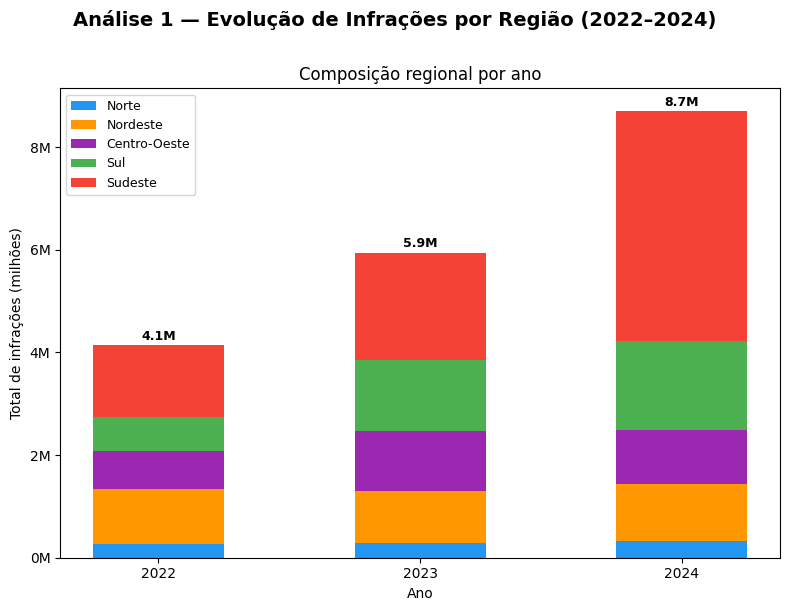

In [37]:
!pip install matplotlib
import matplotlib.ticker as mticker

CORES_REGIAO = {
  'Norte':        '#2196F3',
  'Nordeste':     '#FF9800',
  'Centro-Oeste': '#9C27B0',
  'Sudeste':      '#F44336',
  'Sul':          '#4CAF50',
}
import matplotlib.pyplot as plt
# artefatos visuais plotados
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Análise 1 — Evolução de Infrações por Região (2022–2024)',
             fontsize=14, fontweight='bold', y=1.01)

# gráfico 2: barras empilhadas
df1_pivot = df1.pivot(index='ano', columns='regiao', values='total_infracoes_M').fillna(0)
ordem = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sul', 'Sudeste']
df1_pivot = df1_pivot[[c for c in ordem if c in df1_pivot.columns]]
bottom = pd.Series([0.0] * len(df1_pivot), index=df1_pivot.index)
for regiao in df1_pivot.columns:
    ax.bar(df1_pivot.index.astype(str), df1_pivot[regiao],
            bottom=bottom, color=CORES_REGIAO.get(regiao, '#888'),
            label=regiao, width=0.5)
    bottom = bottom + df1_pivot[regiao]
for i, (ano, tot) in enumerate(bottom.items()):
    ax.text(i, tot + 0.1, f'{tot:.1f}M', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Total de infrações (milhões)')
ax.set_title('Composição regional por ano')
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

plt.tight_layout()
plt.savefig('analise1_regioes.png', dpi=150, bbox_inches='tight')
plt.show()

## Segunda Consulta

In [51]:
SQL_ANALISE_2 = """
SELECT
    v."descrição espécie veículo" AS especie_veiculo,
    v."descrição tipo veículo" AS tipo_veiculo,
    v."indicador veículo estrangeiro" AS estrangeiro,
    COUNT(*) AS total_infracoes,
    ROUND(AVG(f."excesso verificado"::NUMERIC), 2) AS media_excesso_kmh,
    MAX(f."excesso verificado"::NUMERIC) AS maior_excesso_kmh
FROM fato_multa f
JOIN dim_infrator v ON v.id_infrator_sk = f.id_infrator_sk
WHERE
    f."excesso verificado"::NUMERIC > 0
    AND f."excesso verificado"::NUMERIC <= 150 -- Corte de sanidade física (excesso máximo plausível)
    AND v."descrição espécie veículo" NOT IN ('-1', 'Não informado', 'N/I')
    AND v."descrição tipo veículo" NOT IN ('-1', 'Não informado', 'N/I')
GROUP BY v."descrição espécie veículo", v."descrição tipo veículo", v."indicador veículo estrangeiro"
HAVING COUNT(*) >= 100
ORDER BY media_excesso_kmh DESC;
"""
with engine.connect() as conn:
    df2 = pd.read_sql(text(SQL_ANALISE_2), conn)

print(f'Registros limpos retornados: {len(df2)}')
display(df2.head(10))

Registros limpos retornados: 43


,especie_veiculo,tipo_veiculo,estrangeiro,total_infracoes,media_excesso_kmh,maior_excesso_kmh
0,PASSAGEIRO,MOTOCICLO,N,6272,17.46,124.0
1,MISTO,CAMINHONETA,N,45880,17.29,101.0
2,CARGA,MOTOCICLO,N,113,14.98,39.0
3,ESPECIAL,NÃO INFORMADO,N,478,12.95,44.0
4,ESPECIAL,CAMINHAO,N,55604,11.45,106.0
5,ESPECIAL,CAMIONETA,N,2268,11.32,86.0
6,ESPECIAL,CAMINHONETE,N,1100544,9.93,150.0
7,MISTO,UTILITARIO,N,621314,9.45,120.0
8,ESPECIAL,MICROONIBUS,N,452,9.19,55.0
9,ESPECIAL,ONIBUS,N,983,8.56,38.0


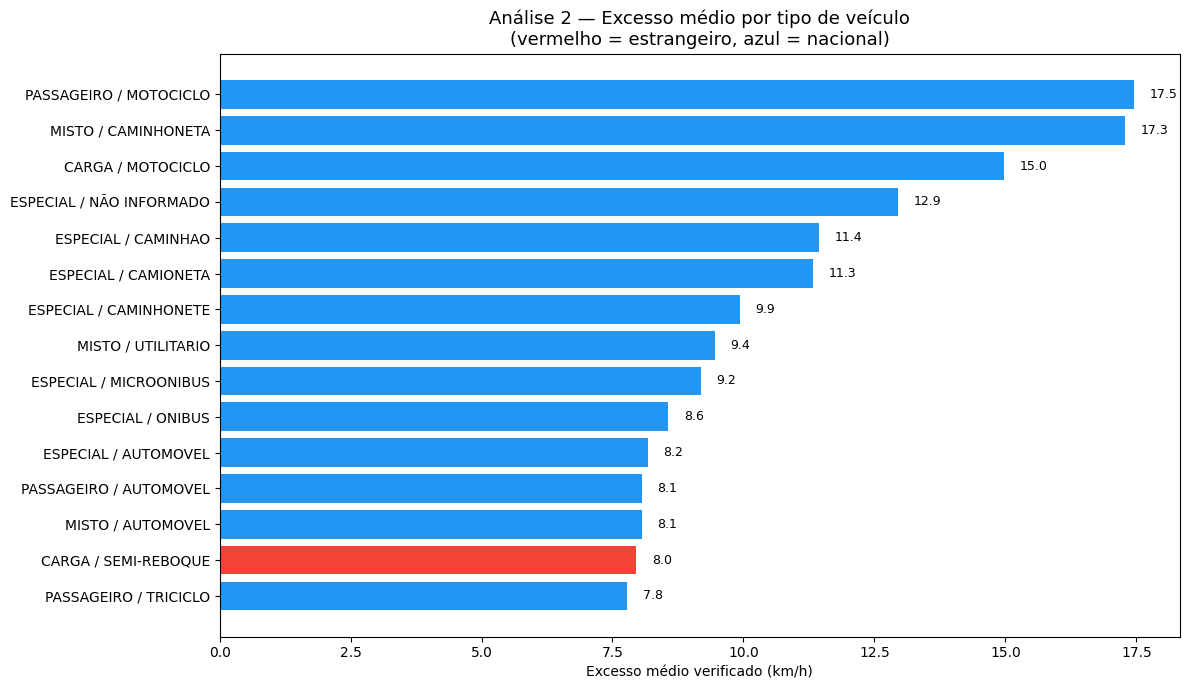

In [49]:
# Gráfico: top 15 combinações por excesso médio
top15 = df2.head(15).copy()
top15['label'] = top15['especie_veiculo'] + ' / ' + top15['tipo_veiculo']
cores = top15['estrangeiro'].map({'S': '#F44336', 'N': '#2196F3'}).fillna('#888')

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15['label'], top15['media_excesso_kmh'], color=cores)

ax.set_xlabel('Excesso médio verificado (km/h)')
ax.set_title('Análise 2 — Excesso médio por tipo de veículo\n(vermelho = estrangeiro, azul = nacional)', fontsize=13)
ax.invert_yaxis()

for bar, val in zip(bars, top15['media_excesso_kmh']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('analise2_veiculos_limpa.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
SQL_OUTLIERS = """
SELECT
    v."descrição espécie veículo",
    v."descrição tipo veículo",
    f."excesso verificado"::NUMERIC AS excesso_kmh
FROM fato_multa f
JOIN dim_infrator v ON v.id_infrator_sk = f.id_infrator_sk
WHERE f."excesso verificado" > 200
ORDER BY excesso_kmh DESC
LIMIT 20;
"""

with engine.connect() as conn:
    df_diag2 = pd.read_sql(text(SQL_OUTLIERS), conn)
display(df_diag2)

,descrição espécie veículo,descrição tipo veículo,excesso_kmh
0,TRAÇÃO,CAMINHAO TRATOR,917235.0
1,CARGA,CAMINHAO,718970.0
2,TRAÇÃO,CAMINHAO TRATOR,681016.0
3,TRAÇÃO,CAMINHAO TRATOR,679923.0
4,TRAÇÃO,CAMINHAO TRATOR,625039.0
5,TRAÇÃO,CAMINHAO TRATOR,596585.0
6,TRAÇÃO,CAMINHAO TRATOR,586325.0
7,CARGA,CAMINHAO TRATOR,522700.0
8,CARGA,CAMINHAO,478127.0
9,TRAÇÃO,CAMINHAO TRATOR,465075.0


# Terceira Consulta

In [54]:
SQL_DIAGNOSTICO = """
SELECT
    i."código da infração"           AS codigo_infracao,
    i."descrição abreviada infração" AS descricao_infracao,
    COUNT(*) AS total_autuacoes,
    ROUND(AVG(NULLIF(f."excesso verificado", 0))::numeric, 2) AS media_excesso_kmh,
    MAX(f."excesso verificado") AS maior_excesso_kmh
FROM fato_multa f
JOIN dim_infracao i ON i.id_infracao_sk = f.id_infracao_sk
GROUP BY
    i."código da infração",
    i."descrição abreviada infração"
ORDER BY total_autuacoes DESC
LIMIT 20;
"""

with engine.connect() as conn:
    df_etl = pd.read_sql(text(SQL_DIAGNOSTICO), conn)

display(df_etl)

,codigo_infracao,descricao_infracao,total_autuacoes,media_excesso_kmh,maior_excesso_kmh
0,74550,Transitar em velocidade superior à máxima perm...,8721819,5.55,32.0
1,74630,Transitar em velocidade superior à máxima perm...,1501928,19.60,67.0
2,59670,Ultrapassar pela contramão linha de divisão de...,650074,NaN,0.0
3,65992,Conduzir o veículo registrado que não esteja d...,610608,NaN,0.0
4,67261,Conduzir o veículo em mau estado de conservaçã...,420980,NaN,0.0
5,58350,Desobedecer às ordens emanadas da autorid comp...,419911,NaN,0.0
6,66700,Conduzir o veículo c/ equip do sistema de ilum...,394195,NaN,0.0
7,51851,Deixar o condutor de usar o cinto segurança,388287,NaN,0.0
8,66450,Conduzir o veículo com equip obrigatório em de...,386975,NaN,0.0
9,50100,Dirigir veículo sem possuir CNH/PPD/ACC,370006,NaN,0.0


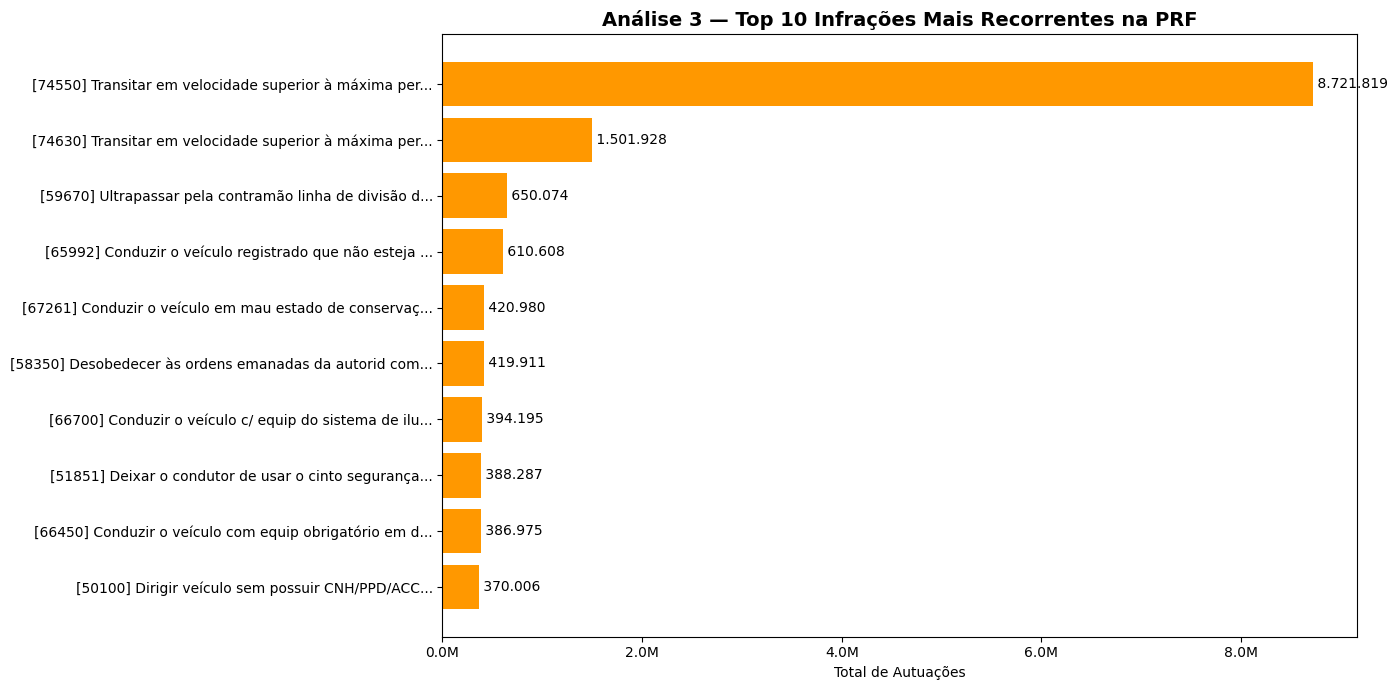

In [55]:
# preparar top 10 a partir dos dados do ETL
top10_infracoes = df_etl.head(10).copy()

# abreviar descrições longas para caber no eixo Y
top10_infracoes['descricao_infracao'] = (
    '[' + top10_infracoes['codigo_infracao'].astype(str) + '] '
    + top10_infracoes['descricao_infracao'].str.slice(0, 45) + '...'
)
# gráfico das 10 infrações mais comuns
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top10_infracoes['descricao_infracao'], top10_infracoes['total_autuacoes'], color='#FF9800')

ax.set_xlabel('Total de Autuações')
ax.set_title('Análise 3 — Top 10 Infrações Mais Recorrentes na PRF', fontsize=14, fontweight='bold')

ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

for bar, val in zip(bars, top10_infracoes['total_autuacoes']):
    texto_formatado = f' {val:,.0f}'.replace(',', '.')
    ax.text(val, bar.get_y() + bar.get_height()/2,
            texto_formatado, va='center', fontsize=10)

plt.tight_layout()
plt.savefig('analise3_top_infracoes.png', dpi=150, bbox_inches='tight')
plt.show()